# 3. Macro and micro drivers: why growth, not only the budget, decides the debt

**Questions.** Why has Italy grown less than its partners since the 1990s, and what does that imply for the debt? How much of the gap in
GDP per capita comes from productivity, hours, employment and demographics? What role do interest rates, inflation, the labour market,
innovation and the structure of firms play? What would closing some of these gaps be worth for the public finances?

**Data.** Eurostat national accounts and labour market (`nama_10_gdp`, `nama_10_pe`, `demo_pjanind`, `lfsi_emp_a`), R&D
(`rd_e_gerdtot`), government bond yields (`irt_lt_mcby_a`), government finance (`gov_10dd_edpt1`).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "public_debt").is_dir())
try:
    import public_debt
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "public_debt"))
    import public_debt
from public_debt import accounting, data, dsa, fiscal, growth, synthetic
from public_debt.var import fit_var1

core = public_debt.require_cpp()

DATA_MODE = os.environ.get("PUBLIC_DEBT_DATA_MODE", "official")   # "official" (Eurostat, IMF) or "synthetic" (offline)
OFFICIAL = DATA_MODE == "official"
OUTPUT_DIR = ROOT / "outputs" / "growth_drivers"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from public_debt.figstyle import (MUTED, NEGATIVE, NOTEBOOK, SERIES, figure_headline, headline, label_ends,
                                  notebook_style, ordinal_colors)
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"public_debt {public_debt.__version__} | data mode: {DATA_MODE}")
if not OFFICIAL:
    print("WARNING: synthetic data. Tables and charts are placeholders, not statistics about Italy.")

public_debt 0.1.0 | data mode: official


## 3.1 Growth: Italy versus its partners

Average real GDP growth by period (%):


,IT,DE,FR,ES,EU27_2020
1996-2007,1.55,1.65,2.41,3.66,2.36
2008-2013,-1.50,0.70,0.50,-1.30,-0.08
2014-2019,0.82,1.92,1.45,2.63,2.12
2020-latest,1.17,0.18,1.02,1.83,1.27


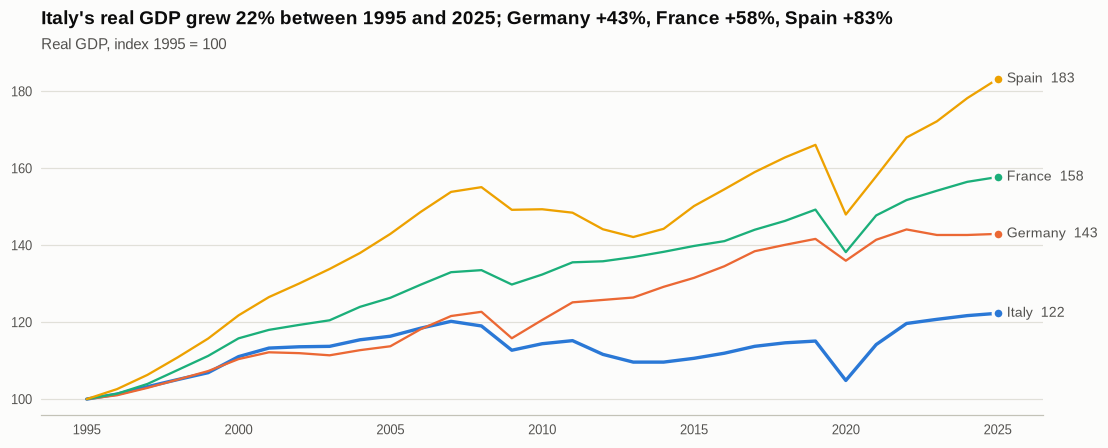

In [2]:
NAMES = {"IT": "Italy", "DE": "Germany", "FR": "France", "ES": "Spain", "EU27_2020": "EU27"}
COLORS = dict(zip(NAMES.values(), SERIES))     # one colour per country in every chart of this notebook
PEERS = ("IT", "DE", "FR", "ES", "EU27_2020")
if OFFICIAL:
    fiscal_by = {g: data.fiscal_dataset(g) for g in PEERS}
    labour_by = {g: data.labour_and_population(g) for g in PEERS if not g.startswith("EU")}
    ind = data.structural_indicators(PEERS)
    yields = data.bond_yields(PEERS)
else:
    fiscal_by = {g: synthetic.fiscal_dataset(seed=20 + k) for k, g in enumerate(PEERS)}
    labour_by = {g: synthetic.labour_and_population(seed=30 + k) for k, g in enumerate(PEERS) if not g.startswith("EU")}
    ind, yields = synthetic.structural_indicators(PEERS), synthetic.bond_yields()
real = pd.DataFrame({g: (1 + f["real_growth"].fillna(0)).cumprod() for g, f in fiscal_by.items()})
real = 100 * real / real.iloc[0]
fig, ax = plt.subplots(figsize=(10, 4))
shown = real.dropna(axis=1, how="all").rename(columns=NAMES)       # series without data get no label
for name in shown:
    ax.plot(shown.index, shown[name], color=COLORS[name], lw=2.2 if name == "Italy" else 1.5)
change = (shown.iloc[-1] - 100).sort_values()
others = ", ".join(f"{name} {v:+.0f}%" for name, v in change.drop("Italy").items())
headline(ax, f"Italy's real GDP grew {change['Italy']:.0f}% between {real.index[0]} and {real.index[-1]}; {others}",
         f"Real GDP, index {real.index[0]} = 100")
label_ends(ax, {name: shown[name].dropna() for name in shown}, COLORS, fmt=lambda v: f"{v:.0f}")
fig.savefig(OUTPUT_DIR / "real_gdp.png", dpi=150)
avg = pd.DataFrame({g: 100 * f["real_growth"].groupby(pd.cut(f.index, [1995, 2007, 2013, 2019, 2100],
                                                              labels=["1996-2007", "2008-2013", "2014-2019", "2020-latest"])).mean()
                    for g, f in fiscal_by.items()})
print("Average real GDP growth by period (%):")
display(avg.round(2))

## 3.2 Growth accounting

$\Delta\ln(Y/P) = \Delta\ln(Y/H) + \Delta\ln(H/E) + \Delta\ln(E/W) + \Delta\ln(W/P)$: productivity per hour, hours per worker,
employment rate of the working-age population and the working-age share. Average annual contributions in percentage points.

GDP per capita  productivity per hour  hours per worker  \
country period                                                                 
IT      1996-2007              1.26                   0.52             -0.21   
        2008-2019             -0.50                   0.06             -0.51   
        2020-latest            1.23                  -0.28              0.35   
DE      1996-2007              1.66                   1.57             -0.42   
        2008-2019              1.15                   0.78             -0.48   
        2020-latest           -0.11                   0.38             -0.44   
FR      1996-2007              1.78                   1.57             -0.30   
        2008-2019              0.50                   0.61             -0.12   
        2020-latest            0.53                  -0.14             -0.05   
ES      1996-2007              2.51                   0.21             -0.20   
        2008-2019              0.30                   1.05             -0.08   
        2020-latest            0.87                   0.44             -0.46   

                     employment rate (15-64)  working-age share  
country period                                                   
IT      1996-2007                       1.31              -0.36  
        2008-2019                       0.19              -0.24  
        2020-latest                     1.30              -0.13  
DE      1996-2007                       0.76              -0.25  
        2008-2019                       1.03              -0.18  
        2020-latest                     0.34              -0.39  
FR      1996-2007                       0.54              -0.03  
        2008-2019                       0.43              -0.42  
        2020-latest                     0.85              -0.13  
ES      1996-2007                       2.40               0.10  
        2008-2019                      -0.31              -0.36  
        2020-latest                     0.79               0.10

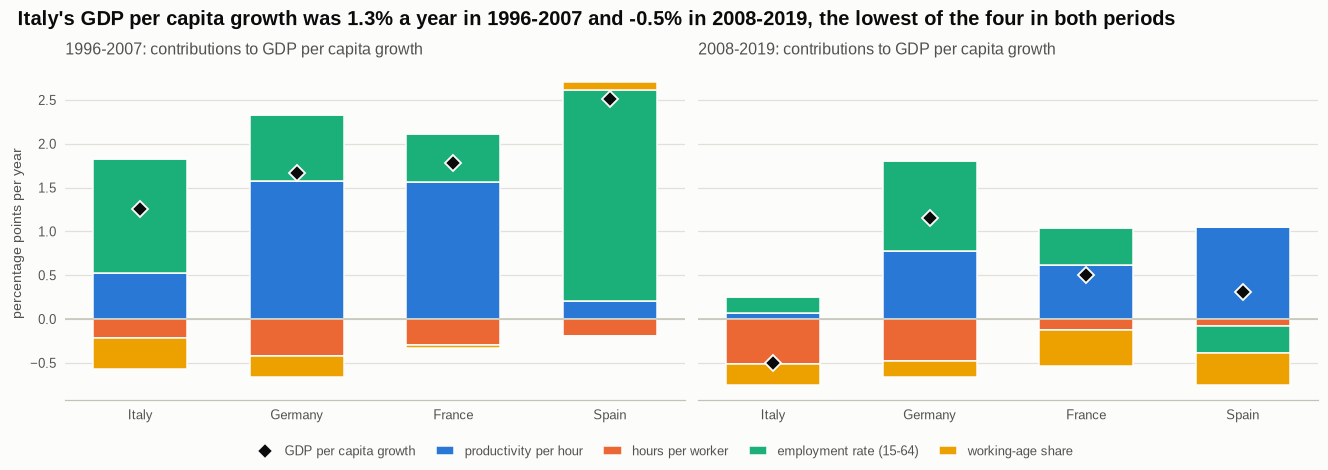

In [3]:
periods = {"1996-2007": (1996, 2007), "2008-2019": (2008, 2019), "2020-latest": (2020, 2100)}
tables = {g: growth.average_by_period(growth.decompose(lp), periods) for g, lp in labour_by.items()}
acc = pd.concat(tables, names=["country", "period"])
display(acc.round(2))
# One panel per period, the same component colours in both, GDP per capita growth as a marker.
parts = acc.drop(columns="GDP per capita")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, period in zip(axes, ["1996-2007", "2008-2019"]):
    block = parts.xs(period, level="period").rename(index=NAMES)
    x = np.arange(len(block))
    pos, neg = np.zeros(len(block)), np.zeros(len(block))
    for column, color in zip(block.columns, SERIES):
        v = block[column].to_numpy()
        ax.bar(x, np.where(v > 0, v, 0), bottom=pos, width=0.6, color=color, label=column)
        ax.bar(x, np.where(v < 0, v, 0), bottom=neg, width=0.6, color=color)
        pos, neg = pos + np.where(v > 0, v, 0), neg + np.where(v < 0, v, 0)
    total = acc.xs(period, level="period")["GDP per capita"].rename(index=NAMES).reindex(block.index)
    ax.plot(x, total.to_numpy(), "D", color=NOTEBOOK["ink"], mec=NOTEBOOK["surface"], mew=1.2, ms=7,
            label="GDP per capita growth")
    ax.axhline(0, color=NOTEBOOK["axis"], lw=1.0)
    ax.set_xticks(x, block.index)
    ax.grid(axis="x", visible=False)
    ax.set(title=f"{period}: contributions to GDP per capita growth")
axes[0].set_ylabel("percentage points per year")
gpc = acc["GDP per capita"].unstack("period").rename(index=NAMES)[["1996-2007", "2008-2019"]]
lowest = all(gpc[p].idxmin() == "Italy" for p in gpc)
figure_headline(fig, f"Italy's GDP per capita growth was {gpc.loc['Italy', '1996-2007']:.1f}% a year in 1996-2007 and "
                     f"{gpc.loc['Italy', '2008-2019']:.1f}% in 2008-2019"
                     + (", the lowest of the four in both periods" if lowest else ""))
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=5)
fig.savefig(OUTPUT_DIR / "growth_accounting.png", dpi=150)

## 3.3 Labour market, demographics and innovation

geo,IT,DE,FR,ES,EU27_2020
employment rate 20-64 (%),67.60,81.10,75.40,72.40,76.10
female employment rate 20-64 (%),58.00,77.70,72.60,67.60,71.30
old-age dependency ratio (%),39.00,35.90,35.50,31.20,34.50
"R&D, % of GDP",1.40,3.10,2.20,1.50,2.20


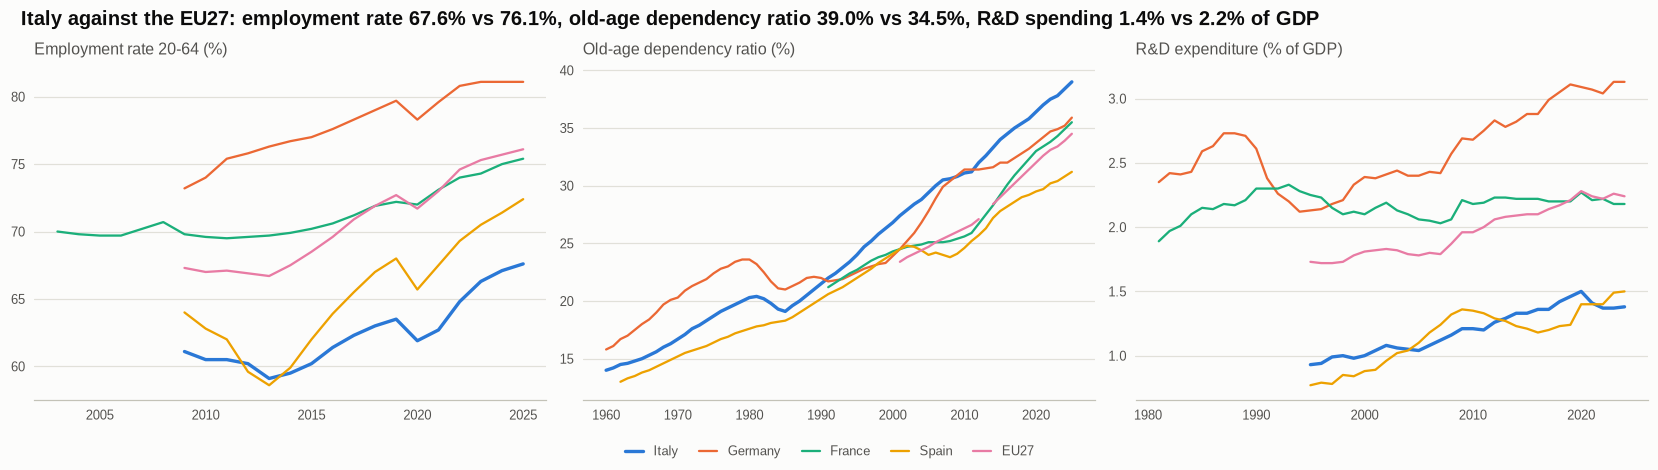

In [4]:
latest = {name: panel.dropna(how="all").iloc[-1] for name, panel in ind.items()}
snap = pd.DataFrame(latest).T
snap.index = ["employment rate 20-64 (%)", "female employment rate 20-64 (%)", "old-age dependency ratio (%)", "R&D, % of GDP"]
display(snap[[g for g in PEERS if g in snap.columns]].round(1))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, key, title in zip(axes, ["employment_rate", "old_age_dependency", "rd_intensity"],
                          ["Employment rate 20-64 (%)", "Old-age dependency ratio (%)", "R&D expenditure (% of GDP)"]):
    frame = ind[key][[g for g in PEERS if g in ind[key]]].rename(columns=NAMES)
    for name in frame:
        ax.plot(frame.index, frame[name], color=COLORS[name], lw=2.2 if name == "Italy" else 1.5, label=name)
    ax.set(title=title)
it_, eu_ = snap["IT"].round(1).to_numpy(), snap["EU27_2020"].round(1).to_numpy()
figure_headline(fig, f"Italy against the EU27: employment rate {it_[0]:.1f}% vs {eu_[0]:.1f}%, old-age dependency ratio "
                     f"{it_[2]:.1f}% vs {eu_[2]:.1f}%, R&D spending {it_[3]:.1f}% vs {eu_[3]:.1f}% of GDP")
handles = {h.get_label(): h for ax in axes for h in ax.get_lines()}
fig.legend([handles[n] for n in NAMES.values() if n in handles], [n for n in NAMES.values() if n in handles],
           loc="outside lower center", ncol=5)
fig.savefig(OUTPUT_DIR / "structural_indicators.png", dpi=150)

## 3.4 Interest rates, spreads and inflation

The spread between Italian and German 10-year yields is the market price of Italy's fiscal and growth risk; it feeds the effective rate on
the debt as bonds are refinanced. Inflation lowers the debt ratio (through nominal GDP) but raises rates.

Average spread by period (bp): 1999-2007: 26, 2008-2013: 211, 2014-2019: 176, 2020-latest: 152


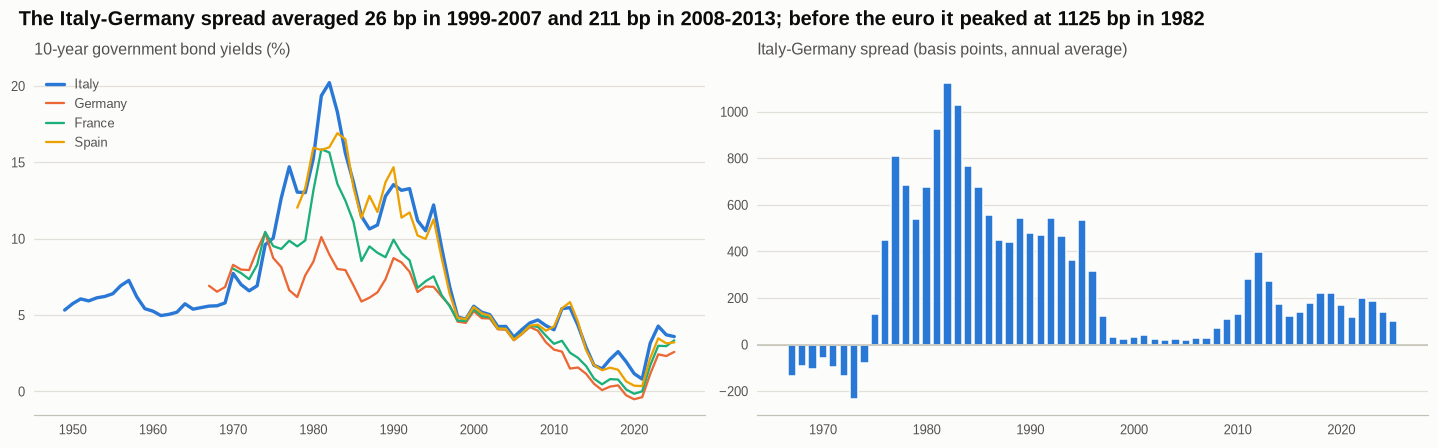

In [5]:
spread = (yields["IT"] - yields["DE"]).dropna()
it = fiscal_by["IT"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for code_ in [c for c in ("IT", "DE", "FR", "ES") if c in yields]:
    axes[0].plot(yields.index, yields[code_], color=COLORS[NAMES[code_]], lw=2.2 if code_ == "IT" else 1.5,
                 label=NAMES[code_])
axes[0].set(title="10-year government bond yields (%)")
axes[0].legend(loc="upper left")
axes[1].bar(spread.index, 100 * spread, color=COLORS["Italy"])
axes[1].axhline(0, color=NOTEBOOK["axis"], lw=1.0)
axes[1].set(title="Italy-Germany spread (basis points, annual average)")
windows = {"1999-2007": (1999, 2007), "2008-2013": (2008, 2013), "2014-2019": (2014, 2019), "2020-latest": (2020, 2100)}
pre = spread.loc[:1998]
figure_headline(fig, f"The Italy-Germany spread averaged {100 * spread.loc[1999:2007].mean():.0f} bp in 1999-2007 and "
                     f"{100 * spread.loc[2008:2013].mean():.0f} bp in 2008-2013"
                     + (f"; before the euro it peaked at {100 * pre.max():.0f} bp in {pre.idxmax()}" if len(pre) else ""))
fig.savefig(OUTPUT_DIR / "spreads.png", dpi=150)
print("Average spread by period (bp): " + ", ".join(f"{k}: {100 * spread.loc[a:b].mean():.0f}"
                                                    for k, (a, b) in windows.items() if not spread.loc[a:b].empty))

## 3.5 What would closing the gaps be worth for the debt?

Illustrative level effects, translated into public finances with the current revenue-to-GDP ratio and fed into the C++ debt projection:

- **Employment**: raising the employment rate to the EU average over ten years, with new workers 30% less productive than the average.
- **Productivity**: 0.5 percentage points more productivity growth per year.

Extra GDP raises revenues roughly in proportion (tax-to-GDP ratio); part of the extra revenue may be spent, so we assume that 50% improves the
primary balance. The debt effect combines the larger denominator and the better primary balance.

In [6]:
it = fiscal_by["IT"]
d0, i0 = float(it["debt"].iloc[-1]), float(it["effective_rate"].iloc[-1])
revenue_ratio = 0.47
emp_gap = float(snap.loc["employment rate 20-64 (%)", "EU27_2020"] - snap.loc["employment rate 20-64 (%)", "IT"]) / 100
horizon = 10
level_emp = max(emp_gap, 0) / max(float(snap.loc["employment rate 20-64 (%)", "IT"]) / 100, 1e-6) * 0.7
extra_growth_emp = (1 + level_emp) ** (1 / horizon) - 1
base = dsa.Scenario.constant(int(it.index.max()) + 1, horizon, growth=0.008, inflation=0.02,
                             market_rate=float(yields["IT"].dropna().iloc[-1]) / 100,
                             primary_balance=float(it["primary_balance"].iloc[-1]))

def with_growth(extra):
    level = np.cumprod(np.full(horizon, 1 + extra)) - 1
    return base.shifted(growth=extra, primary_balance=0.5 * revenue_ratio * level / (1 + level))

runs = {"baseline": base, "employment at EU average": with_growth(extra_growth_emp),
        "productivity +0.5 pp a year": with_growth(0.005)}
proj = {k: dsa.project(d0, i0, 1 / 7, s)["debt"] for k, s in runs.items()}
table = pd.DataFrame({k: 100 * v for k, v in proj.items()})
display(table.iloc[[0, 4, 9]].round(1).T.rename(columns=lambda y: f"debt {y} (%)"))
print(f"Employment gap with the EU: {100 * emp_gap:.1f} points; implied extra growth {100 * extra_growth_emp:.2f} pp a year for {horizon} years")

year,debt 2026 (%),debt 2030 (%),debt 2035 (%)
baseline,136.60,135.60,135.50
employment at EU average,135.30,127.00,113.70
productivity +0.5 pp a year,135.80,130.50,122.40


Employment gap with the EU: 8.5 points; implied extra growth 0.85 pp a year for 10 years


## 3.6 Micro foundations of low growth

Aggregate productivity reflects how firms, markets and institutions work. The evidence for Italy points to:

- **Firm size and management.** A very large share of micro and small firms, often family-managed, with lower adoption of technology and
  management practices; resources are slow to move to the most productive firms (Bank of Italy studies; Bloom and Van Reenen on
  management practices; Eurostat structural business statistics, `sbs_sc_ovw`).
- **Institutions.** Long civil-justice proceedings and administrative burdens reduce investment and firm growth (CEPEJ reports; OECD
  Economic Surveys of Italy).
- **Human capital and innovation.** Low tertiary attainment and R&D intensity compared with peers (section 3.3), skill mismatches and the
  emigration of graduates.
- **Labour market participation.** Low employment of women and young people and large territorial gaps between North and South.
- **Tax compliance.** A large tax gap (the Ministry of Economy's annual report on the non-observed economy and tax evasion estimates it at
  several points of GDP) narrows the tax base and raises statutory rates for compliant taxpayers, with a high tax wedge on labour.
- **Demographics.** Population ageing raises pension and health spending and lowers potential growth (section 3.3; Ageing Report of the
  European Commission).

These factors are the channels through which "structural reforms" can lower the debt ratio: they act on the denominator and on the tax
base, and they are the focus of the National Recovery and Resilience Plan (PNRR).

### References

- Bloom, N. and Van Reenen, J. (2010). Why do management practices differ across firms and countries? *Journal of Economic Perspectives*, 24(1), 203-224.
- European Commission, *Ageing Report* (triennial); OECD, *Economic Surveys: Italy*.
- Ministero dell'Economia e delle Finanze, *Relazione sull'economia non osservata e sull'evasione fiscale e contributiva* (annual).
- Banca d'Italia, *Relazione annuale*; Eurostat, national accounts and labour force statistics.